# 02 — Origin Classification with TF-IDF

Baseline pipeline for country-level origin classification from tasting text. This notebook establishes the lexical-feature reference point every later transformer and LLM experiment is compared against.

Main steps:

1. Load and filter to classes with ≥30 samples
2. Build several preprocessing variants of the Blind Assessment text
3. Stratified 70/15/15 split
4. Grid search over preprocessing × TF-IDF variant × classifier, selected on validation Macro-F1
5. Best-model test evaluation and confusion matrix
6. Training-only resampling experiments (class weights, oversampling, undersampling)

In [1]:
import re
import string
import pandas as pd

from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from nltk.stem import PorterStemmer, WordNetLemmatizer
import matplotlib.pyplot as plt


## Load and filter the dataset

In [2]:
DATA_PATH = 'Data/final_coffee_reviews.csv'
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head(2)

Shape: (7585, 30)


,URL,all_text,Rating,Roaster,Coffee Name,Roaster Location,Coffee Origin,Roast Level,Agtron,Est. Price,...,Who Should Drink It,Bottom Line,Combined_Acidity,Country_all,Country,aroma_text,flavor_text,acidity_text,body_text,combined_text
0,https://www.coffeereview.com/review/100-arabic...,87\nCaribeans\n100% Arabica Coffee from Puerto...,87.0,Caribeans,100% Arabica Coffee from Puerto Rico,"San Juan, Puerto Rico","Utuado, central Puerto Rico",Medium-Light,54/69,$17.00/8 ounces,...,NaN,Satisfying chocolate and nut notes nearly carr...,7.0,Puerto Rico; China,Puerto Rico,NaN,"bittersweet but balanced dark chocolate, dried...","bittersweet but balanced brisk, dry acidity",smooth but rather lean mouthfeel,"bittersweet but balanced dark chocolate, dried..."
1,https://www.coffeereview.com/review/100-arabic...,88\nWaka Coffee\n100% Arabica Freeze-Dried Col...,88.0,Waka Coffee,100% Arabica Freeze-Dried Colombian (Instant C...,"Los Angeles, California",Colombia,NaN,0/0,$10.99/8 single-serve packets,...,NaN,A appealing 100% Colombia coffee in instant fo...,7.0,Colombia,Colombia,NaN,"caramel-toned, richly sweet dark caramel, magn...",sweet-toned in structure with brisk acidity,smooth mouthfeel,"caramel-toned, richly sweet dark caramel, magn..."


In [3]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

coffee_terms_to_keep = {
    'acid', 'acidity', 'aromatic', 'berry', 'bright', 'buttery', 'caramel', 'cherry',
    'chocolate', 'citrus', 'clean', 'cocoa', 'creamy', 'crisp', 'dark', 'drying',
    'earthy', 'finish', 'flavor', 'floral', 'flower', 'fruit', 'fruity', 'honey',
    'jasmine', 'juicy', 'lemon', 'lime', 'mouthfeel', 'nectarine', 'nut', 'nutty',
    'orange', 'peach', 'rose', 'round', 'silky', 'smooth', 'spice', 'spicy', 'stone',
    'sweet', 'syrupy', 'tangerine', 'tea', 'tone', 'vanilla', 'winey'
}
stop_words = set(ENGLISH_STOP_WORDS) - coffee_terms_to_keep

misspelling_replacements = {
    r'\bchocolaty\b': 'chocolate',
    r'\bchoclate\b': 'chocolate',
    r'\bcitrussy\b': 'citrus',
    r'\bcitricy\b': 'citrus',
    r'\bcaramelly\b': 'caramel',
    r'\bcarmel\b': 'caramel',
    r'\bflorals\b': 'floral',
    r'\bfruity\b': 'fruit',
    r'\bnutty\b': 'nut',
    r'\bberries\b': 'berry',
}

phrase_replacements = {
    r'\bdark\s+chocolate\b': 'dark_chocolate',
    r'\bmilk\s+chocolate\b': 'milk_chocolate',
    r'\bbaking\s+chocolate\b': 'baking_chocolate',
    r'\bstone\s+fruit\b': 'stone_fruit',
    r'\borange\s+zest\b': 'orange_zest',
    r'\blemon\s+zest\b': 'lemon_zest',
    r'\bbrown\s+sugar\b': 'brown_sugar',
    r'\bred\s+apple\b': 'red_apple',
    r'\bpipe\s+tobacco\b': 'pipe_tobacco',
    r'\baromatic\s+wood\b': 'aromatic_wood',
    r'\btea\s+rose\b': 'tea_rose',
    r'\bdried\s+berry\b': 'dried_berry',
    r'\bchocolatey\b': 'chocolate',
    r'\bcocoa\s+toned\b': 'cocoa',
    r'\bcitrusy\b': 'citrus',
    r'\bberry\s+like\b': 'berry',
    r'\bberrylike\b': 'berry',
    r'\bfruit\s+toned\b': 'fruit',
    r'\bfloral\s+toned\b': 'floral',
    r'\bnut\s+toned\b': 'nut',
    r'\bcaramel\s+like\b': 'caramel',
    r'\bsweet\s+toned\b': 'sweet',
}


def minimal_raw_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def apply_replacements(text: str) -> str:
    for pattern, replacement in misspelling_replacements.items():
        text = re.sub(pattern, replacement, text)
    for pattern, replacement in phrase_replacements.items():
        text = re.sub(pattern, replacement, text)
    return text


def normalize_text(text: str) -> str:
    text = minimal_raw_text(text).lower()
    text = apply_replacements(text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def remove_domain_stopwords(text: str) -> str:
    tokens = [token for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_stem(text: str) -> str:
    tokens = [stemmer.stem(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_lemmatize(text: str) -> str:
    tokens = [lemmatizer.lemmatize(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


## Build preprocessing variants

In [4]:
# Build text input variants for preprocessing ablation
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['text_basic'] = df['Blind Assessment'].fillna('').map(normalize_text)
df['text_domain_stopwords'] = df['text_basic'].map(remove_domain_stopwords)
df['text_domain_stopwords_stemmed'] = df['text_basic'].map(remove_domain_stopwords_and_stem)
df['text_domain_stopwords_lemmatized'] = df['text_basic'].map(remove_domain_stopwords_and_lemmatize)

# Aspect-based text views from notebook 01
for col in ['aroma_text', 'flavor_text', 'acidity_text', 'body_text', 'combined_text']:
    if col not in df.columns:
        df[col] = ''
    df[col] = df[col].fillna('').astype(str)

df['aspect_text_combined'] = df['combined_text'].map(normalize_text)
df['aspect_text_flavor'] = df['flavor_text'].map(normalize_text)
df['aspect_text_aroma'] = df['aroma_text'].map(normalize_text)
df['aspect_text_acidity'] = df['acidity_text'].map(normalize_text)
df['aspect_text_body'] = df['body_text'].map(normalize_text)
df['text_basic_plus_aspects'] = (
    df['text_basic'].fillna('') + ' ' + df['aspect_text_combined'].fillna('')
).str.replace(r'\s+', ' ', regex=True).str.strip()
df['text_main'] = df['text_basic']

# Use the country label prepared in notebook 01
df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

# Keep valid rows only
work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()

# Remove tiny classes for a stable baseline
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy()

print('Rows after filtering:', len(work))
print('Num classes:', work['origin_country'].nunique())
work['origin_country'].value_counts().head(15)


Rows after filtering: 6820
Num classes: 15


origin_country
Ethiopia         1996
Colombia          988
Kenya             699
Guatemala         561
Indonesia         452
Costa Rica        373
Panama            354
United States     302
El Salvador       240
Brazil            200
Rwanda            176
Peru              130
Nicaragua         125
Honduras          123
Mexico            101
Name: count, dtype: Int64

## Dataset summary and class distribution

In [5]:
dataset_summary = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after preprocessing/filtering',
        'Unique origin classes after filtering',
        'Minimum samples per class',
        'Review date min',
        'Review date max',
    ],
    'value': [
        len(df),
        len(work),
        work['origin_country'].nunique(),
        MIN_SAMPLES_PER_CLASS,
        df['Review Date'].min(),
        df['Review Date'].max(),
    ]
})

dataset_summary


,metric,value
0,Rows in raw dataset,7585
1,Rows after preprocessing/filtering,6820
2,Unique origin classes after filtering,15
3,Minimum samples per class,100
4,Review date min,1997-02-01
5,Review date max,2026-03-01


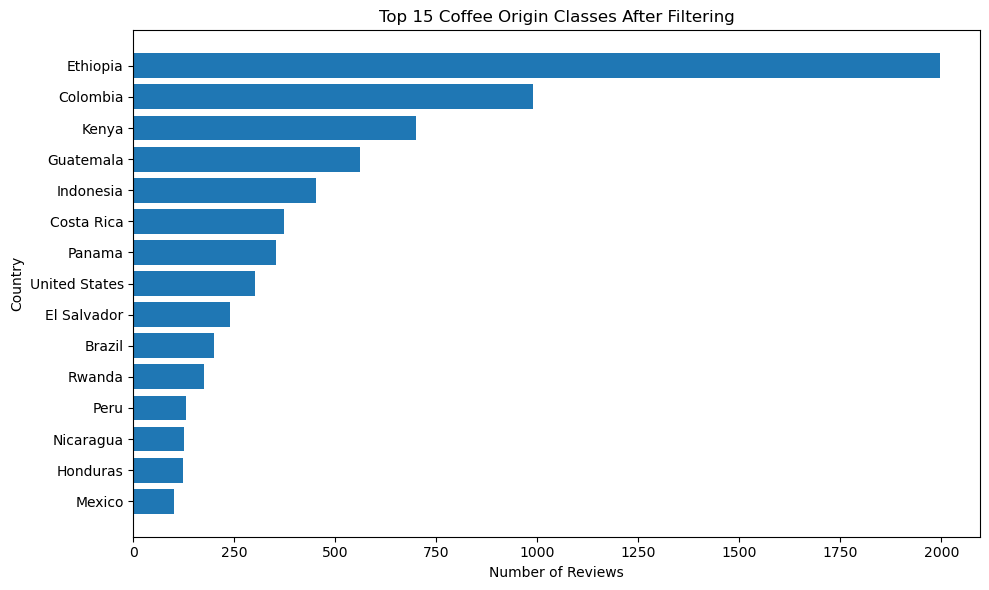

In [6]:
origin_counts = work['origin_country'].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(origin_counts.index, origin_counts.values)
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.title('Top 15 Coffee Origin Classes After Filtering')
plt.tight_layout()
plt.show()


## Stratified 70/15/15 split

In [7]:
work = work.reset_index(drop=True)
y = work['origin_country']
row_idx = work.index

# 70/15/15 split (stratified)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train:', len(train_idx), 'Val:', len(val_idx), 'Test:', len(test_idx))

Train: 4774 Val: 1023 Test: 1023


## Evaluation helper

In [8]:
def evaluate(model, X_data, y_true, split_name='split'):
    y_pred = model.predict(X_data)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    print(f'== {split_name} ==')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Balanced Accuracy: {bal_acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall:    {r:.4f}')
    print(f'F1-macro:  {f1:.4f}')

    return y_pred


## Hyperparameter grid: preprocessing × vectorizer × classifier

In [9]:
preprocessing_variants = {
    'Raw text / punctuation preserved': 'text_raw_minimal',
    'Basic normalization': 'text_basic',
    'Aspect text only': 'aspect_text_combined',
    'Basic normalization + aspect text': 'text_basic_plus_aspects',
    'Aspect text - flavor only': 'aspect_text_flavor',
    'Aspect text - aroma only': 'aspect_text_aroma',
    'Aspect text - acidity only': 'aspect_text_acidity',
    'Aspect text - body only': 'aspect_text_body',
    'Domain stopword removal': 'text_domain_stopwords',
    'Domain stopword removal + stemming': 'text_domain_stopwords_stemmed',
    'Domain stopword removal + lemmatization': 'text_domain_stopwords_lemmatized',
}

ablation_results = []
best_preprocessing_name = None
best_text_column = None
best_preprocessing_val_f1 = -1

for variant_name, column_name in preprocessing_variants.items():
    X_train_variant = work.loc[train_idx, column_name]
    X_val_variant = work.loc[val_idx, column_name]
    X_test_variant = work.loc[test_idx, column_name]

    ablation_model = Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90,
            sublinear_tf=True,
        )),
        ('clf', LinearSVC(
            C=1.0,
            class_weight='balanced',
            dual='auto',
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ])

    ablation_model.fit(X_train_variant, y_train)
    y_val_pred_variant = ablation_model.predict(X_val_variant)
    y_test_pred_variant = ablation_model.predict(X_test_variant)

    val_acc = accuracy_score(y_val, y_val_pred_variant)
    val_bal_acc = balanced_accuracy_score(y_val, y_val_pred_variant)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred_variant, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test, y_test_pred_variant)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred_variant)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred_variant, average='macro', zero_division=0)

    ablation_results.append({
        'preprocessing_variant': variant_name,
        'text_column': column_name,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    })

    if val_f1 > best_preprocessing_val_f1:
        best_preprocessing_val_f1 = val_f1
        best_preprocessing_name = variant_name
        best_text_column = column_name

ablation_results_df = pd.DataFrame(ablation_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
print('Selected preprocessing variant:', best_preprocessing_name)
print('Selected text column:', best_text_column)
ablation_results_df


Selected preprocessing variant: Basic normalization + aspect text
Selected text column: text_basic_plus_aspects


,preprocessing_variant,text_column,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Basic normalization + aspect text,text_basic_plus_aspects,0.316716,0.211344,0.200490,0.211344,0.203546,0.292278,0.179880,0.171044,0.179880,0.174061
1,Raw text / punctuation preserved,text_raw_minimal,0.320626,0.209238,0.202016,0.209238,0.202391,0.310850,0.190796,0.180332,0.190796,0.183815
2,Basic normalization,text_basic,0.321603,0.207633,0.199476,0.207633,0.200785,0.305963,0.185296,0.176734,0.185296,0.179607
3,Domain stopword removal + lemmatization,text_domain_stopwords_lemmatized,0.313783,0.205853,0.193406,0.205853,0.197929,0.312805,0.197440,0.185270,0.197440,0.189373
4,Domain stopword removal,text_domain_stopwords,0.313783,0.201263,0.189384,0.201263,0.193292,0.300098,0.190448,0.180437,0.190448,0.183432
5,Domain stopword removal + stemming,text_domain_stopwords_stemmed,0.308895,0.197540,0.185302,0.197540,0.189356,0.312805,0.192208,0.182043,0.192208,0.185751
6,Aspect text only,aspect_text_combined,0.288368,0.187402,0.174634,0.187402,0.178773,0.267840,0.167457,0.166661,0.167457,0.166176
7,Aspect text - flavor only,aspect_text_flavor,0.270772,0.185412,0.172131,0.185412,0.176212,0.253177,0.171586,0.166339,0.171586,0.166987
8,Aspect text - aroma only,aspect_text_aroma,0.141740,0.112380,0.154303,0.112380,0.112155,0.153470,0.121369,0.159228,0.121369,0.113908
9,Aspect text - acidity only,aspect_text_acidity,0.141740,0.121110,0.105074,0.121110,0.096223,0.136852,0.119740,0.101886,0.119740,0.097268


In [10]:
X_train = work.loc[train_idx, best_text_column]
X_val = work.loc[val_idx, best_text_column]
X_test = work.loc[test_idx, best_text_column]

def build_classifier(params):
    model_name = params['model_name']

    if model_name == 'Logistic Regression':
        return LogisticRegression(
            C=params.get('C', 1.0),
            max_iter=5000,
            solver='liblinear',
            class_weight='balanced',
            multi_class='ovr',
            random_state=RANDOM_STATE,
        )
    if model_name == 'Linear SVM':
        return LinearSVC(
            C=params.get('C', 1.0),
            class_weight='balanced',
            dual='auto',
            max_iter=10000,
            random_state=RANDOM_STATE,
        )
    if model_name == 'SGD Classifier':
        return SGDClassifier(
            loss=params.get('loss', 'hinge'),
            alpha=params.get('alpha', 1e-4),
            class_weight='balanced',
            max_iter=2000,
            tol=1e-3,
            random_state=RANDOM_STATE,
        )
    if model_name == 'Multinomial Naive Bayes':
        return MultinomialNB(alpha=params.get('alpha', 1.0))
    if model_name == 'Complement Naive Bayes':
        return ComplementNB(alpha=params.get('alpha', 1.0))

    raise ValueError(f'Unsupported model_name: {model_name}')

baseline_model_specs = [
    {'model_name': 'Linear SVM', 'C': 1.0},
    {'model_name': 'Logistic Regression', 'C': 1.0},
    {'model_name': 'SGD Classifier', 'loss': 'hinge', 'alpha': 1e-4},
    {'model_name': 'Multinomial Naive Bayes', 'alpha': 1.0},
    {'model_name': 'Complement Naive Bayes', 'alpha': 1.0},
]

baseline_vectorizer_settings = {
    'analyzer': 'word',
    'ngram_range': (1, 2),
    'min_df': 3,
    'max_df': 0.90,
    'sublinear_tf': True,
}

model_benchmark_rows = []
for spec in baseline_model_specs:
    vectorizer = TfidfVectorizer(**baseline_vectorizer_settings)
    model = Pipeline([
        ('tfidf', vectorizer),
        ('clf', build_classifier(spec)),
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0)

    model_benchmark_rows.append({
        'model_name': spec['model_name'],
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    })

model_benchmark_df = pd.DataFrame(model_benchmark_rows).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
model_benchmark_df

# Reduced search space so tuning finishes in a reasonable time on local hardware
search_space = [
    {
        'model_name': ['Logistic Regression'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Linear SVM'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['SGD Classifier'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'loss': ['hinge', 'log_loss'],
        'alpha': [1e-4, 1e-5],
    },
    {
        'model_name': ['Multinomial Naive Bayes'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'alpha': [0.5, 1.0],
    },
    {
        'model_name': ['Complement Naive Bayes'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'alpha': [0.5, 1.0],
    },
    {
        'model_name': ['Logistic Regression'],
        'analyzer': ['char_wb'],
        'ngram_range': [(3, 5)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Linear SVM'],
        'analyzer': ['char_wb'],
        'ngram_range': [(3, 5)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
]

search_results = []
best_model = None
best_params = None
best_val_f1 = -1
print('Total tuned configurations:', sum(len(list(ParameterGrid(grid))) for grid in search_space))

for grid in search_space:
    for params in ParameterGrid(grid):
        vectorizer = TfidfVectorizer(
            analyzer=params['analyzer'],
            ngram_range=params['ngram_range'],
            min_df=params['min_df'],
            max_df=params['max_df'],
            sublinear_tf=params['sublinear_tf'],
        )

        clf = build_classifier(params)

        model = Pipeline([
            ('tfidf', vectorizer),
            ('clf', clf),
        ])

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

        row = dict(params)
        row['val_f1_macro'] = val_f1
        search_results.append(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_params = dict(params)
            best_model = model

search_results_df = pd.DataFrame(search_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
search_results_df.head(10)


Total tuned configurations: 56


,C,analyzer,max_df,min_df,model_name,ngram_range,sublinear_tf,val_f1_macro,alpha,loss
0,1.0,word,0.9,2,Linear SVM,"(1, 2)",True,0.205377,NaN,NaN
1,5.0,word,0.9,2,Logistic Regression,"(1, 2)",True,0.205192,NaN,NaN
2,NaN,word,0.9,2,SGD Classifier,"(1, 2)",True,0.199650,0.00010,log_loss
3,NaN,word,0.9,2,SGD Classifier,"(1, 2)",True,0.199422,0.00001,log_loss
4,5.0,word,0.9,5,Linear SVM,"(1, 2)",True,0.196830,NaN,NaN
5,5.0,word,0.9,2,Logistic Regression,"(1, 1)",True,0.196667,NaN,NaN
6,1.0,word,0.9,5,Logistic Regression,"(1, 2)",True,0.195940,NaN,NaN
7,1.0,char_wb,0.9,5,Logistic Regression,"(3, 5)",True,0.194810,NaN,NaN
8,NaN,word,0.9,5,SGD Classifier,"(1, 2)",True,0.194479,0.00010,log_loss
9,5.0,char_wb,0.9,2,Logistic Regression,"(3, 5)",True,0.193955,NaN,NaN


## Best model — validation and test metrics

In [11]:
print('Best validation F1-macro:', round(best_val_f1, 4))
best_params


Best validation F1-macro: 0.2054


{'C': 1,
 'analyzer': 'word',
 'max_df': 0.9,
 'min_df': 2,
 'model_name': 'Linear SVM',
 'ngram_range': (1, 2),
 'sublinear_tf': True}

In [12]:
_ = evaluate(best_model, X_val, y_val, 'Validation (Best Tuned TF-IDF Model)')
y_test_pred_best = evaluate(best_model, X_test, y_test, 'Test (Best Tuned TF-IDF Model)')

print('\nTop classes report (test, best tuned model):')
top_labels = y_test.value_counts().head(15).index
print(classification_report(y_test, y_test_pred_best, labels=top_labels, zero_division=0))


== Validation (Best Tuned TF-IDF Model) ==
Accuracy:  0.3216
Balanced Accuracy: 0.2116
Precision: 0.2034
Recall:    0.2116
F1-macro:  0.2054
== Test (Best Tuned TF-IDF Model) ==
Accuracy:  0.3118
Balanced Accuracy: 0.1769
Precision: 0.1721
Recall:    0.1769
F1-macro:  0.1742

Top classes report (test, best tuned model):
               precision    recall  f1-score   support

     Ethiopia       0.49      0.47      0.48       299
     Colombia       0.26      0.24      0.25       148
        Kenya       0.57      0.57      0.57       105
    Guatemala       0.22      0.21      0.22        84
    Indonesia       0.47      0.56      0.51        68
   Costa Rica       0.17      0.16      0.17        56
       Panama       0.09      0.09      0.09        53
United States       0.09      0.09      0.09        45
  El Salvador       0.03      0.03      0.03        36
       Brazil       0.14      0.17      0.15        30
       Rwanda       0.00      0.00      0.00        27
         Peru    

## Confusion matrix on the top 10 classes

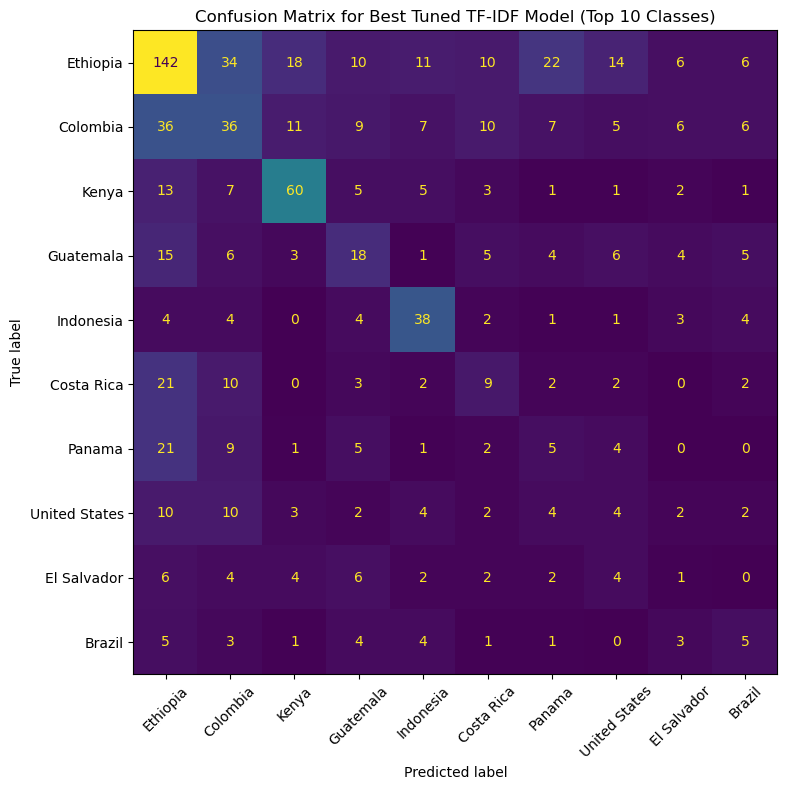

In [13]:
top_confusion_labels = y_test.value_counts().head(10).index
cm = confusion_matrix(y_test, y_test_pred_best, labels=top_confusion_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_confusion_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix for Best Tuned TF-IDF Model (Top 10 Classes)')
plt.tight_layout()
plt.show()


## Training-only resampling experiments

In [14]:
def build_model_from_params(params):
    vectorizer = TfidfVectorizer(
        analyzer=params['analyzer'],
        ngram_range=params['ngram_range'],
        min_df=params['min_df'],
        max_df=params['max_df'],
        sublinear_tf=params['sublinear_tf'],
    )

    clf = build_classifier(params)

    return Pipeline([
        ('tfidf', vectorizer),
        ('clf', clf),
    ])

def metric_row_explicit(label, y_val_true, y_val_pred, y_test_true, y_test_pred):
    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_bal_acc = balanced_accuracy_score(y_val_true, y_val_pred)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val_true, y_val_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test_true, y_test_pred)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test_true, y_test_pred, average='macro', zero_division=0)

    return {
        'experiment': label,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    }


In [15]:
# Resampling is applied only on the training split to avoid leakage
train_df = pd.DataFrame({
    'text': X_train.reset_index(drop=True),
    'label': y_train.reset_index(drop=True),
})

max_train_count = train_df['label'].value_counts().max()
min_train_count = train_df['label'].value_counts().min()

oversampled_parts = []
undersampled_parts = []
for label, group in train_df.groupby('label'):
    oversampled_parts.append(group.sample(n=max_train_count, replace=True, random_state=RANDOM_STATE))
    undersampled_parts.append(group.sample(n=min_train_count, replace=False, random_state=RANDOM_STATE))

train_over = pd.concat(oversampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
train_under = pd.concat(undersampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('Original training rows:', len(train_df))
print('Oversampled training rows:', len(train_over))
print('Undersampled training rows:', len(train_under))


Original training rows: 4774
Oversampled training rows: 20955
Undersampled training rows: 1065


In [16]:
best_model_train_original = build_model_from_params(best_params)
best_model_train_original.fit(X_train, y_train)
y_val_pred_original = best_model_train_original.predict(X_val)
y_test_pred_original = best_model_train_original.predict(X_test)

best_model_train_over = build_model_from_params(best_params)
best_model_train_over.fit(train_over['text'], train_over['label'])
y_val_pred_over = best_model_train_over.predict(X_val)
y_test_pred_over = best_model_train_over.predict(X_test)

best_model_train_under = build_model_from_params(best_params)
best_model_train_under.fit(train_under['text'], train_under['label'])
y_val_pred_under = best_model_train_under.predict(X_val)
y_test_pred_under = best_model_train_under.predict(X_test)


In [17]:
resampling_results_df = pd.DataFrame([
    metric_row_explicit('Class weighting only', y_val, y_val_pred_original, y_test, y_test_pred_original),
    metric_row_explicit('Class weighting + oversampled training set', y_val, y_val_pred_over, y_test, y_test_pred_over),
    metric_row_explicit('Class weighting + undersampled training set', y_val, y_val_pred_under, y_test, y_test_pred_under),
]).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

resampling_results_df


,experiment,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Class weighting + oversampled training set,0.319648,0.194005,0.195945,0.194005,0.191471,0.311828,0.180197,0.176223,0.180197,0.177786
1,Class weighting only,0.321603,0.211638,0.203351,0.211638,0.205377,0.311828,0.176914,0.172108,0.176914,0.174166
2,Class weighting + undersampled training set,0.176931,0.154788,0.142834,0.154788,0.135864,0.179863,0.163396,0.154782,0.163396,0.143311
